In [59]:
import pandas as pd
from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [60]:
df = pd.read_csv("merged_df_v1_mobility.csv")

In [65]:
# Adding a new column with classifications
df['Binary'] = df['quality_mapped'].apply(lambda x: 1 if x >= 720 else 0)

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

In [11]:
X = df[['Level','Qual','SNR']]
y = df['Binary']

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [13]:
random_state_var = 42


Model: Logistic Regression
Classification Report:
               precision    recall  f1-score   support

         Low       0.65      0.77      0.70       507
        High       0.58      0.44      0.50       376

    accuracy                           0.63       883
   macro avg       0.61      0.60      0.60       883
weighted avg       0.62      0.63      0.62       883



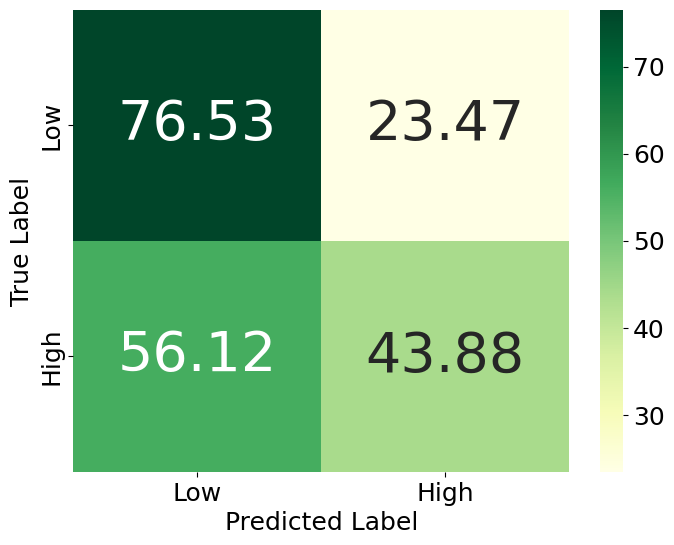

[[76.52859961 23.47140039]
 [56.11702128 43.88297872]]
Cross-validation scores (5 folds): [0.65291262 0.63834951 0.65533981 0.68446602 0.66504854]
Accuracies:  0.6592233009708738
Mean CV Accuracy: 0.6592233009708738
Test Accuracy: 0.6262740656851642

Model: Decision Tree
Classification Report:
               precision    recall  f1-score   support

         Low       0.74      0.84      0.79       507
        High       0.74      0.60      0.66       376

    accuracy                           0.74       883
   macro avg       0.74      0.72      0.73       883
weighted avg       0.74      0.74      0.73       883



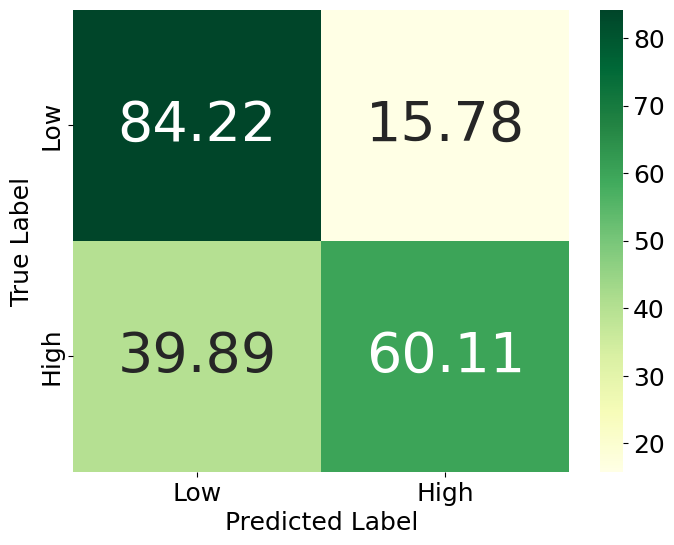

[[84.2209073  15.7790927 ]
 [39.89361702 60.10638298]]
Cross-validation scores (5 folds): [0.73300971 0.72572816 0.72087379 0.76699029 0.73543689]
Accuracies:  0.7364077669902913
Mean CV Accuracy: 0.7364077669902913
Test Accuracy: 0.739524348810872

Model: Random Forest
Classification Report:
               precision    recall  f1-score   support

         Low       0.77      0.84      0.80       507
        High       0.75      0.66      0.70       376

    accuracy                           0.76       883
   macro avg       0.76      0.75      0.75       883
weighted avg       0.76      0.76      0.76       883



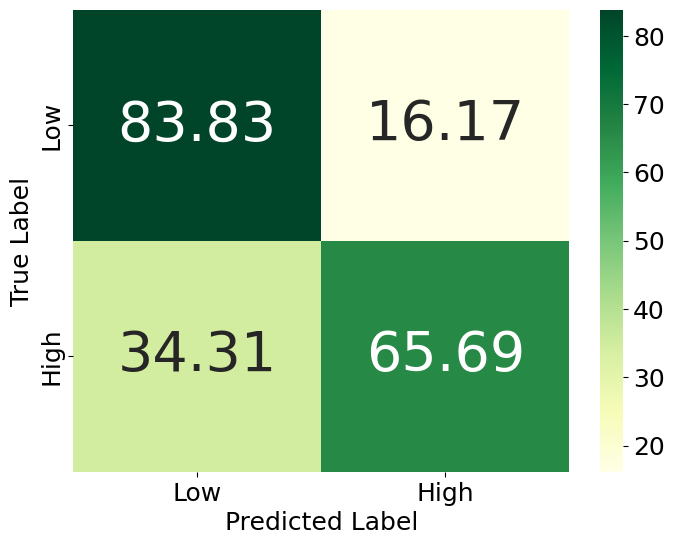

[[83.82642998 16.17357002]
 [34.30851064 65.69148936]]
Cross-validation scores (5 folds): [0.73543689 0.72572816 0.74271845 0.75728155 0.76456311]
Accuracies:  0.7451456310679612
Mean CV Accuracy: 0.7451456310679612
Test Accuracy: 0.7610419026047565

Model: Support Vector Machine (SVM)
Classification Report:
               precision    recall  f1-score   support

         Low       0.68      0.84      0.75       507
        High       0.69      0.48      0.56       376

    accuracy                           0.68       883
   macro avg       0.68      0.66      0.66       883
weighted avg       0.68      0.68      0.67       883



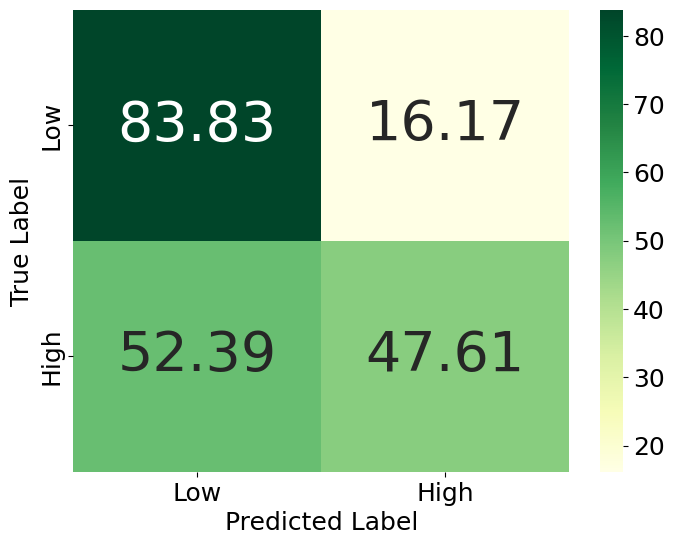

[[83.82642998 16.17357002]
 [52.39361702 47.60638298]]
Cross-validation scores (5 folds): [0.69660194 0.6868932  0.66990291 0.72572816 0.72087379]
Accuracies:  0.7000000000000001
Mean CV Accuracy: 0.7000000000000001
Test Accuracy: 0.6840317100792752


In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state_var)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=random_state_var),
    "Decision Tree": DecisionTreeClassifier(random_state=random_state_var),
    "Random Forest": RandomForestClassifier(random_state=random_state_var),
    "Support Vector Machine (SVM)": SVC(probability=True,random_state=random_state_var)
}

# Train, predict, and evaluate each model
for name, model in models.items():
    print(f"\nModel: {name}")
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Print performance metrics
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Low', 'High']))
    
    # Confusion Matrix
    # cm = confusion_matrix(y_test, y_pred)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
    # disp.plot(cmap=plt.cm.Blues)
    # plt.title(f"Confusion Matrix: {name}")
    # plt.show()

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    # Convert counts to percentages
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    # Define class labels
    # labels = label_encoder.classes_
    # Plot using seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap="YlGn", xticklabels=['Low','High'], yticklabels=['Low','High'], annot_kws={"size": 40})
    # Titles and labels
    plt.xticks(fontsize=18)  # Increase x-axis tick labels font size
    plt.yticks(fontsize=18)  # Increase y-axis tick labels font size
    # plt.title("Confusion Matrix (Percentage)")
    plt.xlabel("Predicted Label", fontsize=18)
    plt.ylabel("True Label", fontsize=18)
    # Adjust the colorbar label size
    cbar = plt.gca().collections[0].colorbar  # Get colorbar
    cbar.ax.tick_params(labelsize=18)  # Increase colorbar font size

    plt.savefig("cms/"+str(name)+".pdf")
    # Show plot
    plt.show()
    print(cm_percentage)

    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print("Cross-validation scores (5 folds):", cv_scores)
    print("Accuracies: ", sum(cv_scores) / len(cv_scores))
    print("Mean CV Accuracy:", np.mean(cv_scores))
    print("Test Accuracy:", model.score(X_test, y_test))

In [17]:
# !pip install xgboost

Accuracy for each fold: [0.72572816 0.7184466  0.72330097 0.73786408 0.75970874]
Mean CV Accuracy: 0.7330097087378641
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.84      0.79       507
           1       0.74      0.61      0.67       376

    accuracy                           0.74       883
   macro avg       0.74      0.72      0.73       883
weighted avg       0.74      0.74      0.74       883



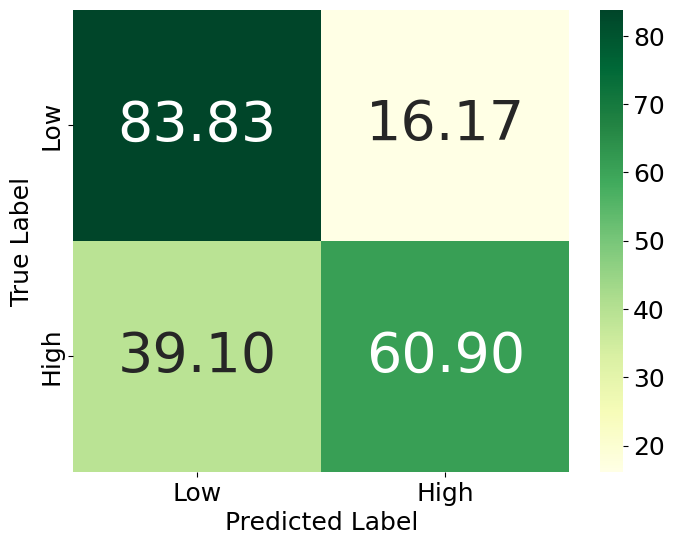

Test Score (Accuracy on test set): 0.7407


In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# XGBoost model
xgb = XGBClassifier(eval_metric='logloss',random_state=random_state_var)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='accuracy')

# Print fold-wise accuracy
print("Accuracy for each fold:", cv_scores)

# Print mean accuracy
print("Mean CV Accuracy:", cv_scores.mean())

# Fit the model on the entire training data
xgb.fit(X_train, y_train)

# Calculate the accuracy on the test set
test_score = xgb.score(X_test, y_test)

# Predictions
y_pred = xgb.predict(X_test)

# Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
# disp.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix: XGBoost")
# plt.show()
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
# Define class labels
# labels = label_encoder.classes_
# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap="YlGn", xticklabels=['Low','High'], yticklabels=['Low','High'], annot_kws={"size": 40})
# Titles and labels
plt.xticks(fontsize=18)  # Increase x-axis tick labels font size
plt.yticks(fontsize=18)  # Increase y-axis tick labels font size
# plt.title("Confusion Matrix (Percentage)")
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
cbar = plt.gca().collections[0].colorbar  # Get colorbar
cbar.ax.tick_params(labelsize=18)
plt.savefig("cms/xgboost.pdf")
# Show plot
plt.show()

# Print test score (accuracy on test set)
print(f"Test Score (Accuracy on test set): {test_score:.4f}")

Accuracy for each fold: [0.72330097 0.73300971 0.68446602 0.76456311 0.74029126]
Mean CV Accuracy: 0.729126213592233
Test Accuracy: 0.7576
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.87      0.81       507
           1       0.78      0.60      0.68       376

    accuracy                           0.76       883
   macro avg       0.76      0.74      0.74       883
weighted avg       0.76      0.76      0.75       883



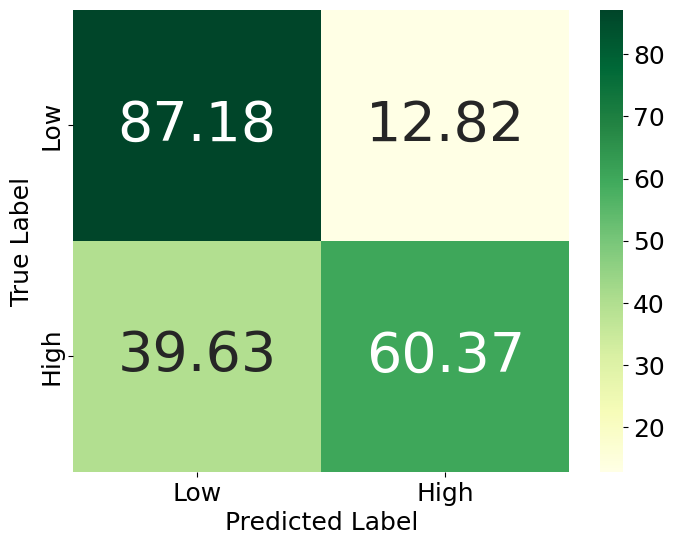

In [20]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define base models
base_models = [
    ('lr', LogisticRegression(random_state=random_state_var)),
    ('dt', DecisionTreeClassifier(random_state=random_state_var)),
    ('svc', SVC(probability=True,random_state=random_state_var)),
    ('xgb', XGBClassifier(eval_metric='logloss',random_state=random_state_var)),  # Add XGBoost as a base model
    ('rf', RandomForestClassifier(random_state=random_state_var))  # Add Random Forest as a base model
]

# Define the final meta-model (Random Forest)
stack_model = StackingClassifier(estimators=base_models, final_estimator=RandomForestClassifier())

# 5-Fold Cross-Validation
cv_scores = cross_val_score(stack_model, X_train, y_train, cv=5, scoring='accuracy')

# Print fold-wise accuracy and mean accuracy
print("Accuracy for each fold:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# Fit the model on the entire training set
stack_model.fit(X_train, y_train)

# Test Accuracy
test_accuracy = stack_model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions
y_pred = stack_model.predict(X_test)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
# disp.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix: StackingClassifier")
# plt.show()
cm = confusion_matrix(y_test, y_pred)
# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
# Define class labels
# labels = label_encoder.classes_
# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap="YlGn", xticklabels=['Low','High'], yticklabels=['Low','High'], annot_kws={"size": 40})
# Titles and labels
plt.xticks(fontsize=18)  # Increase x-axis tick labels font size
plt.yticks(fontsize=18)  # Increase y-axis tick labels font size
# plt.title("Confusion Matrix (Percentage)")
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
# Adjust the colorbar label size
cbar = plt.gca().collections[0].colorbar  # Get colorbar
cbar.ax.tick_params(labelsize=18)  # Increase colorbar font size

plt.savefig("cms/stacking.pdf")
# Show plot
plt.show()

Accuracy for each fold: [0.76941748 0.72330097 0.75       0.76699029 0.77427184]
Mean CV Accuracy: 0.7567961165048545
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.87      0.81       507
           1       0.78      0.64      0.70       376

    accuracy                           0.77       883
   macro avg       0.77      0.75      0.76       883
weighted avg       0.77      0.77      0.76       883



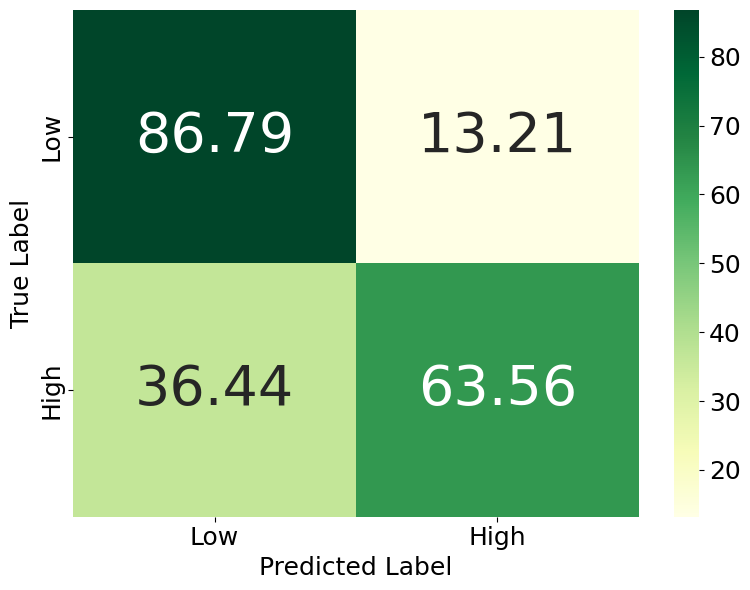

Test Score (Accuracy on test set): 0.7690


In [22]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Define base models
lr = LogisticRegression(random_state=random_state_var)
dt = DecisionTreeClassifier(random_state=random_state_var)
svc = SVC(probability=True,random_state=random_state_var)
xgb = XGBClassifier(eval_metric='logloss',random_state=random_state_var)
rf = RandomForestClassifier(random_state=random_state_var)

# Define Voting Classifier (Soft Voting)
voting_model = VotingClassifier(estimators=[
    ('lr', lr),
    ('dt', dt),
    ('svc', svc),
    ('xgb', xgb),
    ('rf', rf)
], voting='soft')

# Perform 5-fold cross-validation
cv_scores = cross_val_score(voting_model, X_train, y_train, cv=5, scoring='accuracy')

# Print fold-wise accuracy
print("Accuracy for each fold:", cv_scores)

# Print mean accuracy across all folds
print("Mean CV Accuracy:", cv_scores.mean())

# Fit the model on the entire training data (for test set evaluation)
voting_model.fit(X_train, y_train)

# Calculate accuracy on the test set
test_score = voting_model.score(X_test, y_test)

# Predictions on test set
y_pred = voting_model.predict(X_test)

# Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
# disp.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix: Voting Classifier")
# plt.show()
cm = confusion_matrix(y_test, y_pred)
# Convert counts to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
# Define class labels
# labels = label_encoder.classes_
# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap="YlGn", xticklabels=['Low','High'], yticklabels=['Low','High'], annot_kws={"size": 40})
# Titles and labels
plt.xticks(fontsize=18)  # Increase x-axis tick labels font size
plt.yticks(fontsize=18)  # Increase y-axis tick labels font size
# plt.title("Confusion Matrix (Percentage)")
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
# Adjust the colorbar label size
cbar = plt.gca().collections[0].colorbar  # Get colorbar
cbar.ax.tick_params(labelsize=18)  # Increase colorbar font size

plt.savefig("cms/vooting.pdf")
plt.tight_layout()
# Show plot
plt.show()
# Print test score (accuracy on test set)
print(f"Test Score (Accuracy on test set): {test_score:.4f}")
